In [ ]:
pip install geopandas

     |████████████████████████████████| 1.0 MB 12.2 MB/s 
     |████████████████████████████████| 16.7 MB 45.4 MB/s 
     |████████████████████████████████| 6.3 MB 62.2 MB/s 


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
regions = gpd.read_file('/content/drive/MyDrive/Capstone - data/TSDM/District_Boundary.shp')
regions.sample(5)

,Area,Shape_Leng,Shape_Area,No_HH,TOT_P,TOT_M,TOT_F,P_06,M_06,F_06,P_SC,M_SC,F_SC,P_ST,M_ST,F_ST,Dist_Name,geometry
21,1294.451557,2.093210,129445.155684,269180.0,1080867.0,541301.0,539557.0,100918.0,52106.0,48812.0,196046.0,97433.0,98613.0,33306.0,17274.0,16032.0,Warangal Urban,"POLYGON ((79.56420 18.26239, 79.56486 18.26234..."
28,3980.341589,3.688098,398034.158929,156683.0,708972.0,356407.0,352565.0,87292.0,45198.0,42094.0,99422.0,49242.0,50180.0,224622.0,112953.0,111669.0,Adilabad,"POLYGON ((78.33344 19.88466, 78.33378 19.88463..."
11,7218.261624,4.630144,721826.162424,401728.0,1618416.0,818306.0,800110.0,181996.0,94926.0,87070.0,292951.0,145964.0,146987.0,209252.0,109272.0,99980.0,Nalgonda,"POLYGON ((79.26616 17.36021, 79.26967 17.35997..."
14,2195.386919,2.197566,219538.691923,209677.0,795332.0,399325.0,396007.0,66812.0,34772.0,32040.0,154855.0,77311.0,77544.0,14945.0,7520.0,7425.0,Peddapalli,"POLYGON ((79.48108 18.81585, 79.48292 18.81404..."
30,4495.317152,4.706601,449531.715176,120258.0,515053.0,257814.0,257239.0,66069.0,33993.0,32076.0,80976.0,40817.0,40159.0,133534.0,65823.0,67711.0,Kumurambheem Asifabad,"POLYGON ((79.28435 19.59600, 79.28468 19.59592..."


In [ ]:
data = pd.read_excel('/content/drive/MyDrive/Capstone - data/Existing Godowns 2 (1).xlsx')
(data.tail(40))

,District,Godowns,Capacity
0,Adilabad,5.0,13000.0
1,Bhadradri Kothagudem,11.0,18500.0
2,Jagtial,11.0,23500.0
3,Jangoan,6.0,11000.0
4,Jogulamba Gadwal,1.0,1000.0
5,Kamareddy,8.0,21500.0
6,Karimnagar,10.0,30000.0
7,Khammam,13.0,36500.0
8,Kumurambheem Asifabad,1.0,2000.0
9,Mahabubabad,5.0,5000.0


In [ ]:
regions['Dist_Name'] = regions['Dist_Name'].str.upper()
data['District'] = data['District'].str.upper()

In [ ]:
merged = regions.set_index('Dist_Name').join(data.set_index('District'))
merged.head(5)
merged = merged.reset_index()

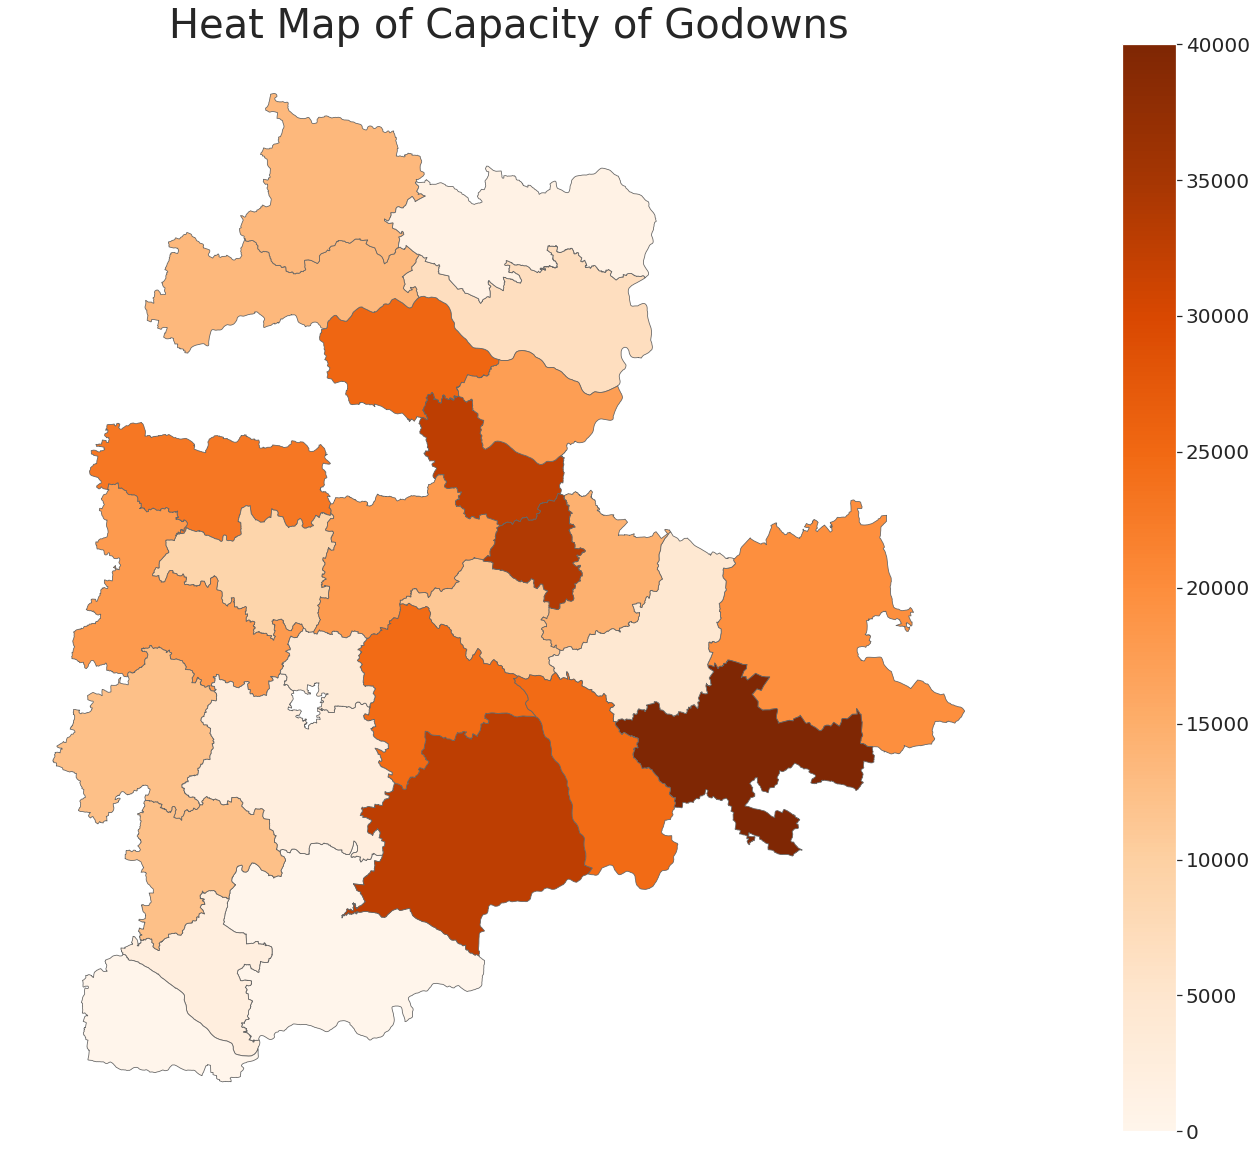

In [ ]:
fig, ax = plt.subplots(1, figsize=(40, 20))
ax.axis('off')
ax.set_title('Heat Map of Capacity of Godowns', fontdict={'fontsize': '40', 'fontweight' : '3'})
color = 'Oranges'
vmin, vmax = 0,40000
sm = plt.cm.ScalarMappable(cmap=color, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm)
cbar.ax.tick_params(labelsize=20)
merged.plot('Capacity', cmap=color, linewidth=0.8, ax=ax, figsize=(40,20),edgecolor=".4")

In [ ]:
df=pd.read_excel('/content/drive/MyDrive/Capstone - data/Road and Buildings (Length in KMs).xlsx')
df.head()

,Districts,State Highways,Major District Roads,Rural Roads
0,ADILABAD,80.0,123.0,301.0
1,BHADRADRI,104.0,410.0,420.0
2,HYDERABAD,37.0,5.0,77.0
3,JAGTIAL,0.0,222.0,461.0
4,JANGAON,28.0,564.0,49.0


<Figure size 14400x36000 with 0 Axes>

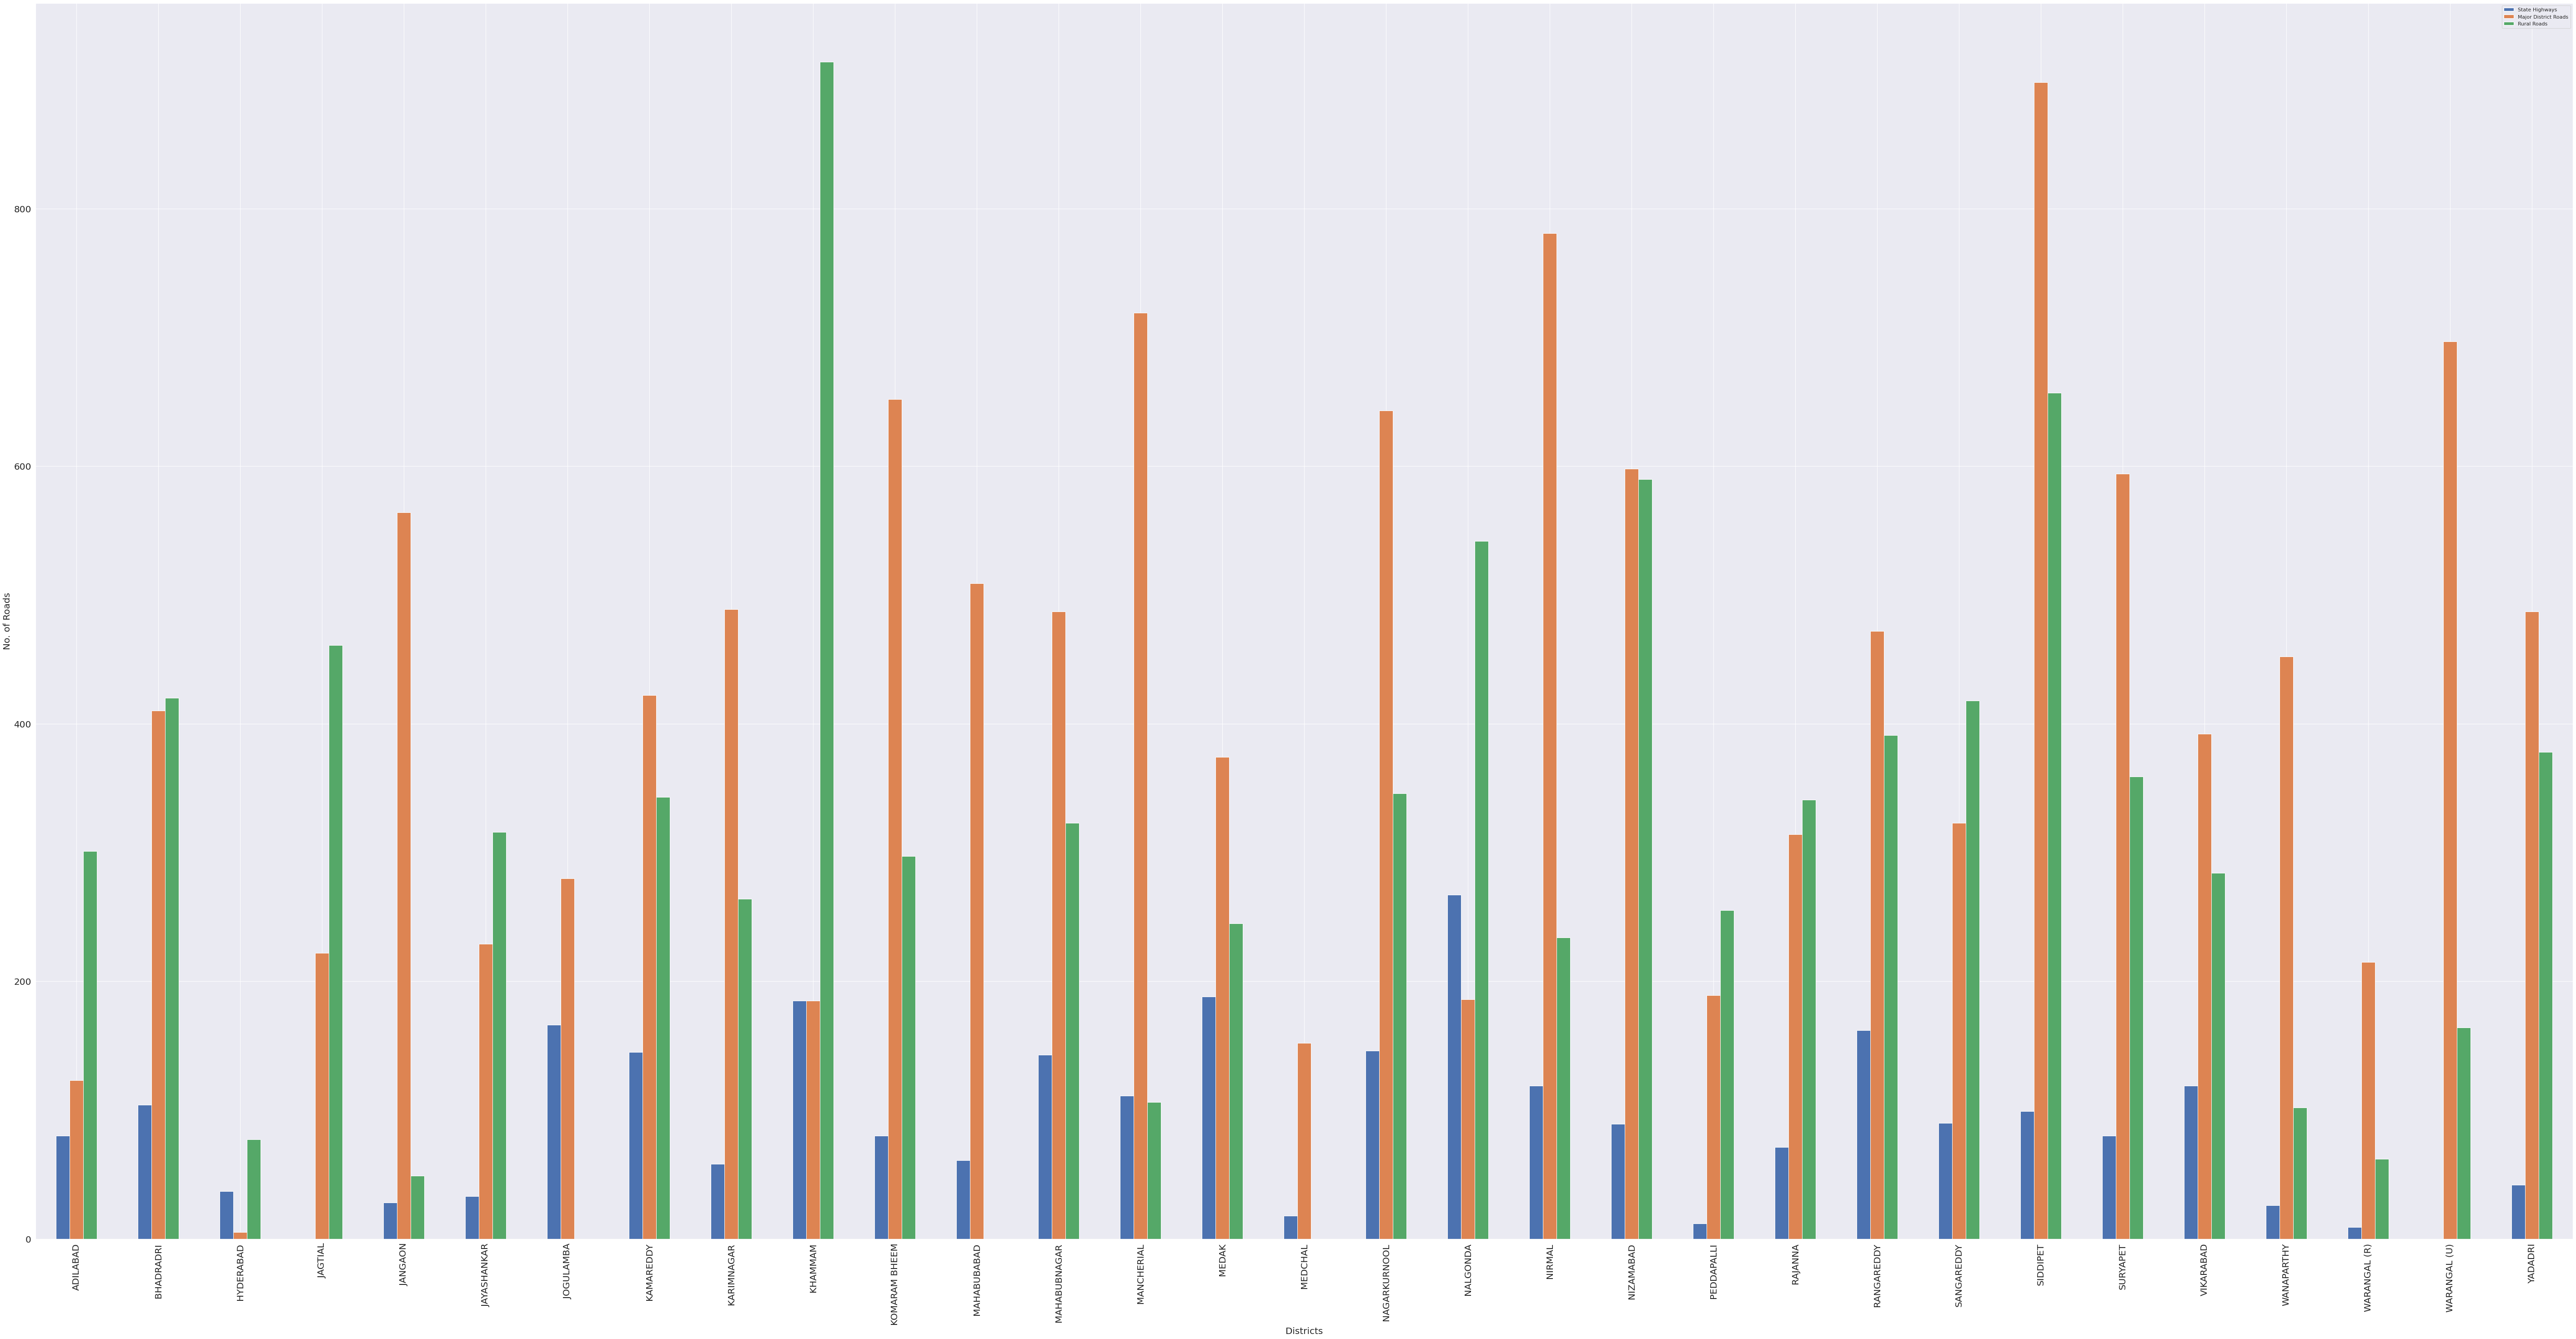

<Figure size 14400x36000 with 0 Axes>

In [ ]:
ax = df.plot.bar(x='Districts', y=['State Highways','Major District Roads', 'Rural Roads'], rot=0)
plt.yticks(fontsize=20)
plt.xticks(rotation=90, fontsize=20)
plt.xlabel('Districts', fontsize=20)
plt.ylabel('No. of Roads', fontsize=20)
plt.figure(figsize=(200,500))